d:\Data\Git Projects\langchainupdated\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


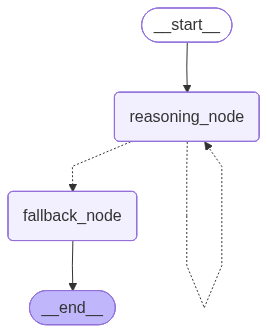

In [1]:
# runtime context using dataclass
# graph = StateGraph(State, context_schema=ContextSchema) ContextSchema is the dataclass here

# Proactive recursion handling

from IPython.core.display import Image
from IPython.core.display_functions import display
from typing_extensions import TypedDict
from typing import Annotated, Literal
from langgraph.graph import StateGraph, START,END
from langgraph.managed import RemainingSteps

class State(TypedDict):
    messages: Annotated[list, lambda x,y: x+y]
    remaining_steps: RemainingSteps # managed value - tracks steps until limit is reached

def reasoning_node(state:State)->dict:
    # RemainingSteps is automaticaly populated by langgraph
    remaining = state["remaining_steps"]

    # Check if we are remaining low on steps
    if remaining <=2:
        return {"messages":["Approaching limit, wrapping up..."]}

    # normal processing
    return {"messages":[f"thinking... ({remaining} steps remaining)"]}


def routing_decision(state:State) -> Literal["reasoning_node","fallback_node"]:
    """Route based on remaining steps""" 
    if state["remaining_steps"] <=2:
        return "fallback_node"
    return "reasoning_node"

def fallback_node(state:State) -> dict:
    """Handle cases where recursion limit is approaching""" 
    return {"messages":["Reached complexity limit, providing best effort answer"]}

# build graph
builder = StateGraph(State)
builder.add_node("reasoning_node", reasoning_node)
builder.add_node("fallback_node", fallback_node)
builder.add_edge(START,"reasoning_node")
builder.add_conditional_edges("reasoning_node",routing_decision)
builder.add_edge("fallback_node",END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [5]:
from pprint import pprint
from langgraph.errors import GraphRecursionError

# remaining steps works with any recursion_limit
try:
 result = graph.invoke({"messages":[]}, {"recursion_limit":10})
except GraphRecursionError as e:
    # Handle externally after graph execution fails
    result = {"messages":[f"error occured: {e}"]}

pprint(result)
# for message in result["messages"]:
#     message.pretty_print()

{'messages': ['thinking... (9 steps remaining)',
              'thinking... (8 steps remaining)',
              'thinking... (7 steps remaining)',
              'thinking... (6 steps remaining)',
              'thinking... (5 steps remaining)',
              'thinking... (4 steps remaining)',
              'thinking... (3 steps remaining)',
              'Approaching limit, wrapping up...',
              'Reached complexity limit, providing best effort answer']}
